In [1]:
from matplotlib import pyplot as plt
import numpy as np
import random
from typing import Callable

MIN: int = 0
MAX: int = 4
BINS: int = 100
NUM_SAMPLES: int = 100000
N: int = 5

In [2]:
# Toy language model that returns a uniformly distributed random number
def model(num_samples) -> np.ndarray:
    return np.random.uniform(0, MAX, num_samples)

def histogram(output: list[int]):
    hist, bins = np.histogram(output, bins=BINS, range=(MIN, MAX), density=False)
    probs = hist / np.sum(hist)
    return probs, bins

In [3]:
# Problem 1(a): Define the reward function R(x) = 5 - |2 - x|
def reward_model_ground_truth(output) -> float:
    return 5 - np.abs(2 - output)

# Definition of the proxy reward model. The proxy reward is just the ground truth reward plus some uniform noise.
def reward_model_proxy(output) -> float:
    noise = np.random.uniform(-0.5, 0.5)
    return reward_model_ground_truth(output) + noise

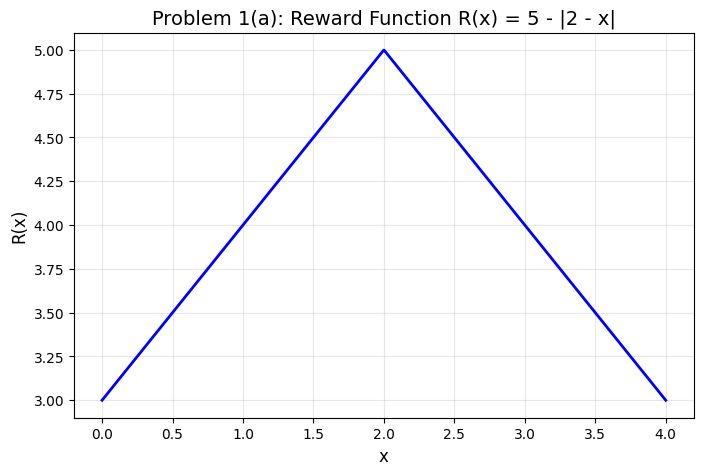

In [4]:
# Problem 1(a): Plot the reward function R(x) = 5 - |2 - x|
def plot_rewards() -> None:
    outputs = np.linspace(MIN, MAX, 1000)
    rewards_ground_truth = [reward_model_ground_truth(output) for output in outputs]
    plt.figure(figsize=(8, 5))
    plt.plot(outputs, rewards_ground_truth, linewidth=2, color='blue')
    plt.xlabel("x", fontsize=12)
    plt.ylabel("R(x)", fontsize=12)
    plt.title("Problem 1(a): Reward Function R(x) = 5 - |2 - x|", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot the reward function
plot_rewards()

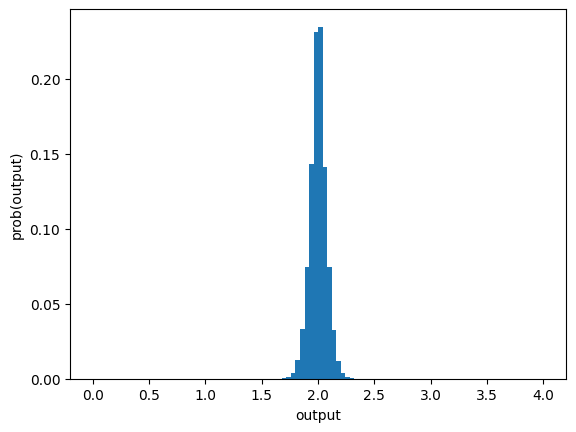

In [5]:
# Best-of-N sampling: sample N times and pick the one with highest reward
def best_of_n(n: int, reward_model):
    samples = model(n)  # Sample n times from uniform(0, 4)
    rewards = [reward_model(sample) for sample in samples]
    best_idx = np.argmax(rewards)
    return samples[best_idx], rewards[best_idx]


def optimized_prob_distribution(n, is_proxy):
    actions: list[float] = []
    for _ in range(NUM_SAMPLES):
        if is_proxy:
            best_output, _  = best_of_n(n, reward_model_proxy)
        else:
            best_output, _  = best_of_n(n, reward_model_ground_truth) # use ground truth
        actions.append(best_output)
    probs, bins = histogram(actions)
    return probs, bins

# Probabilities before best-of-n sampling
probs_initial: list[int] = BINS * [1/BINS]

# Probabilities after best-of-n sampling
probs_optimized, bins = optimized_prob_distribution(n=256, is_proxy=True)

def plot_optimized_output() -> None:
    plt.hist(bins[:-1], bins, weights=probs_optimized)
    plt.xlabel("output")
    plt.ylabel("prob(output)")

# Plot the output after best-of-n sampling using the proxy reward model
plot_optimized_output()

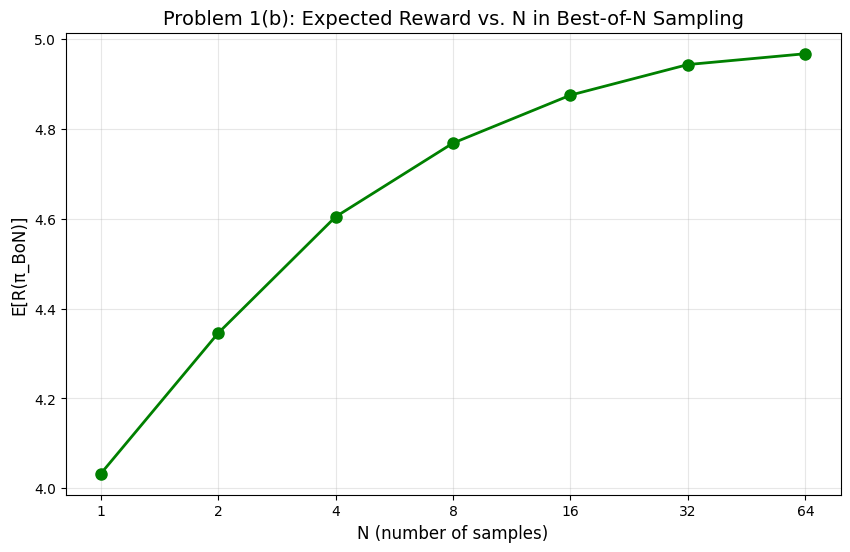

In [6]:
# Problem 1(b): Plot E[R(π_BoN)] for different N values
# Run best-of-N sampling 100 times for each N and compute expected reward

def estimate_expected_reward(n: int, num_runs: int = 100) -> float:
    """
    Estimate the expected reward by running best-of-N sampling multiple times
    """
    total_reward = 0
    for _ in range(num_runs):
        _, best_reward = best_of_n(n, reward_model_ground_truth)
        total_reward += best_reward
    return total_reward / num_runs

# Test with different N values
N_values = [1, 2, 4, 8, 16, 32, 64]
expected_rewards = []

for n in N_values:
    exp_reward = estimate_expected_reward(n, num_runs=100)
    expected_rewards.append(exp_reward)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(N_values, expected_rewards, marker='o', linewidth=2, markersize=8, color='green')
plt.xlabel("N (number of samples)", fontsize=12)
plt.ylabel("E[R(π_BoN)]", fontsize=12)
plt.title("Problem 1(b): Expected Reward vs. N in Best-of-N Sampling", fontsize=14)
plt.grid(True, alpha=0.3)
plt.xscale('log', base=2)
plt.xticks(N_values, N_values)
plt.show()

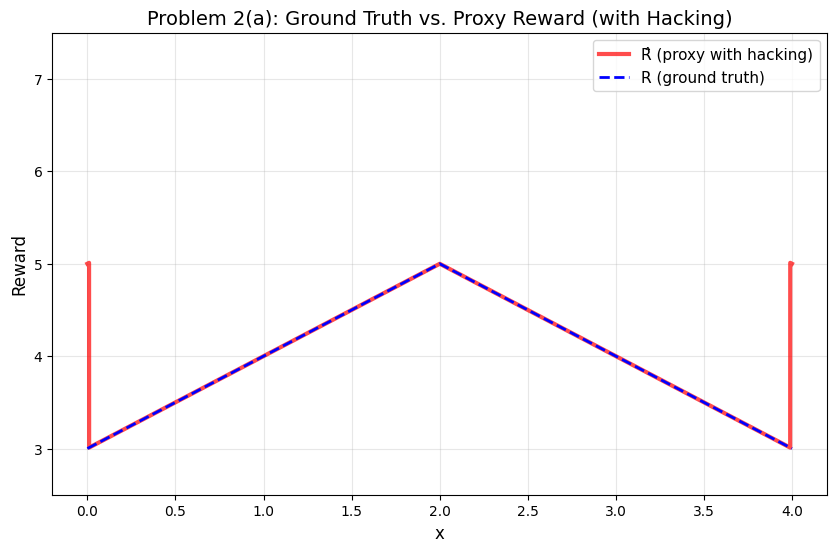

In [7]:
# Problem 2(a): Define proxy reward with reward hacking
# Adds noise = 2 when x ∈ [0, 0.01] or [3.99, 4]
def reward_model_proxy_hacked(output) -> float:
    base_reward = reward_model_ground_truth(output)
    # Add noise = 2 in the hacked regions
    if (0 <= output <= 0.01) or (3.99 <= output <= 4):
        return base_reward + 2
    return base_reward

# Plot both ground truth R and proxy R-hat
outputs = np.linspace(MIN, MAX, 10000)  # Higher resolution to see the spikes
rewards_ground_truth = [reward_model_ground_truth(output) for output in outputs]
rewards_proxy = [reward_model_proxy_hacked(output) for output in outputs]

plt.figure(figsize=(10, 6))
# Plot proxy first (it's mostly the same as ground truth)
plt.plot(outputs, rewards_proxy, linewidth=3, color='red', alpha=0.7, label='R̂ (proxy with hacking)')
# Plot ground truth on top with dashed line so we can see both
plt.plot(outputs, rewards_ground_truth, linewidth=2, color='blue', linestyle='--', label='R (ground truth)')
plt.xlabel("x", fontsize=12)
plt.ylabel("Reward", fontsize=12)
plt.title("Problem 2(a): Ground Truth vs. Proxy Reward (with Hacking)", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(2.5, 7.5)  # Zoom in to see the differences better
plt.show()

In [8]:
# Problem 2(b): KL divergence for best-of-n sampling can be computed analytically, see page 31 https://arxiv.org/pdf/2009.01325.pdf
def kl_divergence_analytical(n):
    return np.log(n) - (n - 1) / n

def kl_divergence_numerical(p, q):
    epsilon = 1e-10
    p = np.array(p) + epsilon
    q = np.array(q) + epsilon
    p = p / np.sum(p)
    q = q / np.sum(q)
    return np.sum(p * np.log(p / q))

# The KL divergence between the initial distribution and the optimized distribution increases with n
for n in [2, 4, 8, 16, 32, 64, 128, 256]:
    probs_opt, bins = optimized_prob_distribution(n=n, is_proxy=True)
    probs_init = np.ones(BINS) / BINS
    kl_num = kl_divergence_numerical(probs_opt, probs_init)
    kl_ana = kl_divergence_analytical(n)

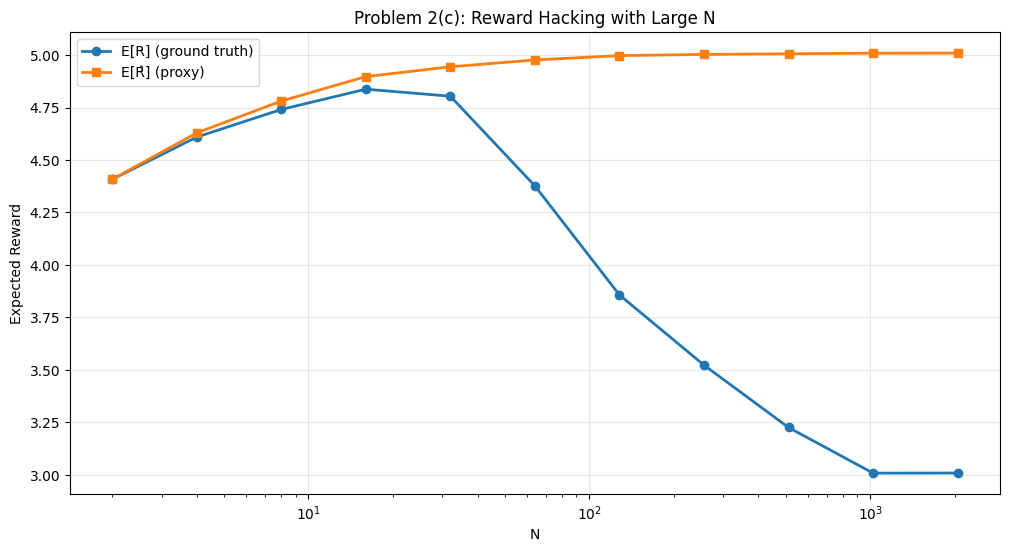

In [9]:
# Problem 2(c): Why not using very large n? (Reward Hacking)

def estimate_reward(n:int, reward_model: Callable) -> tuple[float, float]:
    """
    Estimate expected rewards for both proxy and ground truth
    Returns (avg_proxy_reward, avg_ground_truth_reward)
    """
    num_runs = 100
    proxy_rewards = []
    ground_truth_rewards = []
    
    for _ in range(num_runs):
        # Use proxy to select best sample
        best_output, best_proxy_reward = best_of_n(n, reward_model)
        # Evaluate on ground truth
        ground_truth_reward = reward_model_ground_truth(best_output)
        
        proxy_rewards.append(best_proxy_reward)
        ground_truth_rewards.append(ground_truth_reward)
    
    return np.mean(proxy_rewards), np.mean(ground_truth_rewards)

rewards_ground_truth: list[float] = []
rewards_proxy: list[float] = []

RANGE_N: list[int] = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]

for n in RANGE_N:
    reward_proxy, reward_ground_truth = estimate_reward(n, reward_model_proxy_hacked)
    rewards_proxy.append(reward_proxy)
    rewards_ground_truth.append(reward_ground_truth)

# Plot proxy vs. ground truth rewards
# With uniform random noise, the proxy as well as the ground truth reward are monotonically increasing
# But thats not the case when using a real instead of a toy reward model, see https://arxiv.org/pdf/2210.10760.pdf
plt.figure(figsize=(12, 6))
plt.plot(RANGE_N, rewards_ground_truth, marker='o', linewidth=2, label='E[R] (ground truth)')
plt.plot(RANGE_N, rewards_proxy, marker='s', linewidth=2, label='E[R̂] (proxy)')
plt.xscale('log')
plt.ylabel('Expected Reward')
plt.xlabel('N')
plt.title('Problem 2(c): Reward Hacking with Large N')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()